# On dataset PhishingVsBenignURL 
* Throughout we see an increase in accuracy with the increase of depth. From depth 1-6 we see a significant increase both with Gini and Entropy 



In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('~/Desktop/DataSetForPhishingVSBenignUrl.csv')
df




,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.500000,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.000000,Defacement
1,0,4,5,5.500000,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.000000,-1.000000,Defacement
2,0,4,5,5.500000,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.000000,-1.000000,Defacement
3,0,4,12,5.500000,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.000000,-1.000000,Defacement
4,0,4,6,5.500000,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.000000,-1.000000,Defacement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36702,29,4,14,5.750000,12,3.666667,4,20,24,3,...,3,2,7,0.690555,0.791265,0.777498,0.690227,0.656684,0.796205,spam
36703,0,4,13,3.750000,8,8.461538,4,24,23,0,...,16,15,-1,0.665492,0.820010,0.879588,0.674400,0.674671,-1.000000,spam
36704,58,3,27,6.666666,16,3.375000,3,41,34,20,...,8,7,9,0.656807,0.801139,0.684777,0.713622,0.717187,0.705245,spam
36705,35,3,13,4.333334,9,3.600000,3,15,13,7,...,9,8,3,0.725963,0.897617,0.871049,0.745932,0.758824,0.790772,spam


Text(0, 0.5, 'numbers')

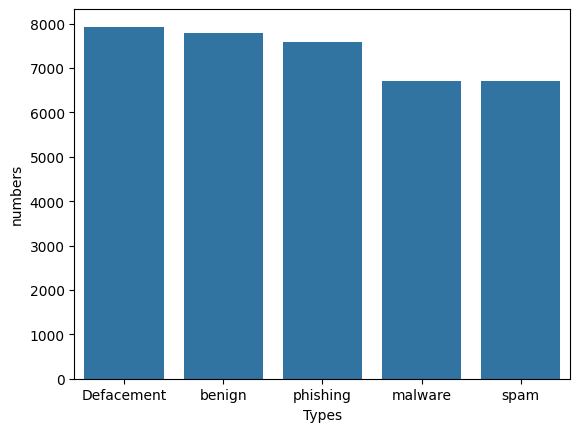

In [2]:
y = df['URL_Type_obf_Type']

y_count = y.index

count = df['URL_Type_obf_Type'].value_counts()

sns.barplot(x = count.index, y = count)
plt.xlabel('Types')
plt.ylabel('numbers')


In [3]:

df = df.dropna()
new_names = df.columns[:79]
print(new_names)



Index(['Querylength', 'domain_token_count', 'path_token_count',
       'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld',
       'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path',
       'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path',
       'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength',
       'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio',
       'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio',
       'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL',
       'ISIpAddressInDomainName', 'CharacterContinuityRate',
       'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount',
       'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount',
       'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count',
       'Directory_LetterCount', 'Filename_LetterCount',
       'Extension_LetterCount', 'Query_LetterCount', 'LongestPathToken

In [4]:

from sklearn.preprocessing import StandardScaler
X = df.iloc[: , :79]
y = df['URL_Type_obf_Type']

class_names = y.unique()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size = 0.2, random_state = 100)

# Decision tree with depth 1 

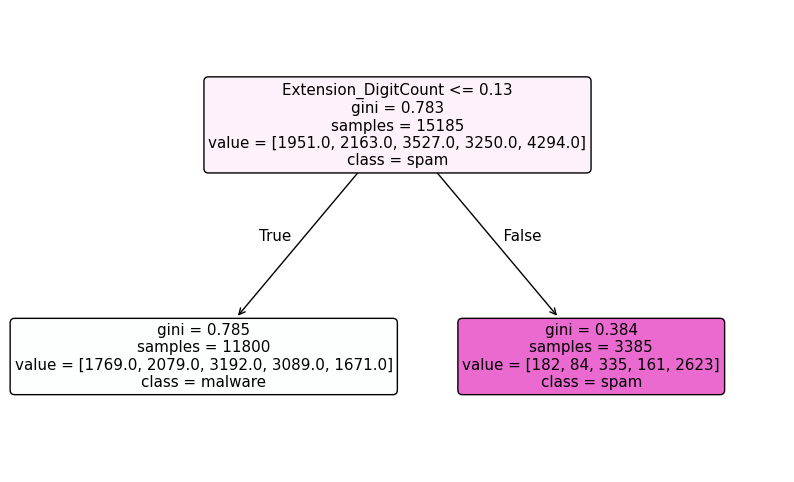

In [21]:


from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn import tree
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

decision= DecisionTreeClassifier(criterion = "gini", random_state = 50,
     max_depth=1)
decision.fit(X_train, y_train)


plt.figure(figsize=(10, 6))
plot_tree(
    decision,
    feature_names=new_names,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.show()



In [24]:
y_pred_gini = decision.predict(X_test)

print("Gini accuracy decision tree: ", accuracy_score(y_test,y_pred_gini) * 100, " %")

Gini accuracy decision tree:  38.82012114827496  %


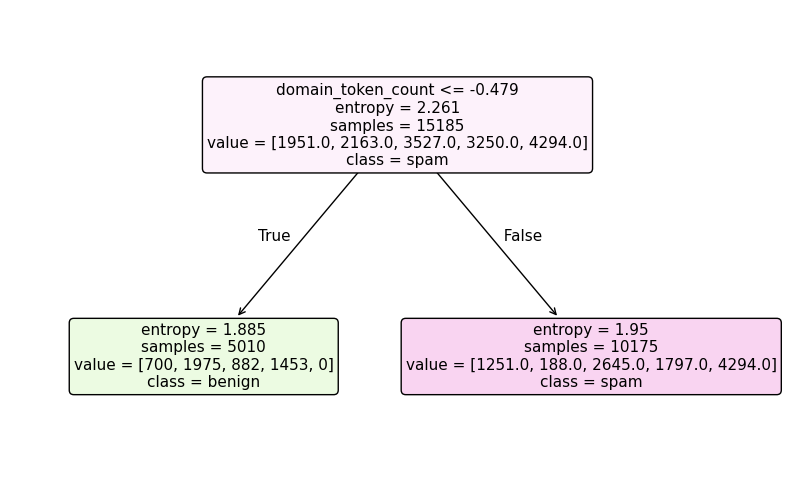

In [29]:
tree_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 50,
    max_depth=1)
tree_entropy.fit(X_train, y_train)



plt.figure(figsize=(10,6))
plot_tree(tree_entropy, 
          feature_names=new_names,
          class_names=class_names,
          filled=True, rounded=True)
plt.show()


In [31]:
pred_entropy = tree_entropy.predict(X_test)

# Accuracy for Decision Tree classifier with criterion as gini index
print("Entropy accuracy: ", accuracy_score(y_test,pred_entropy) * 100, " %")

Entropy accuracy:  40.479325783513296  %


# Depth 2

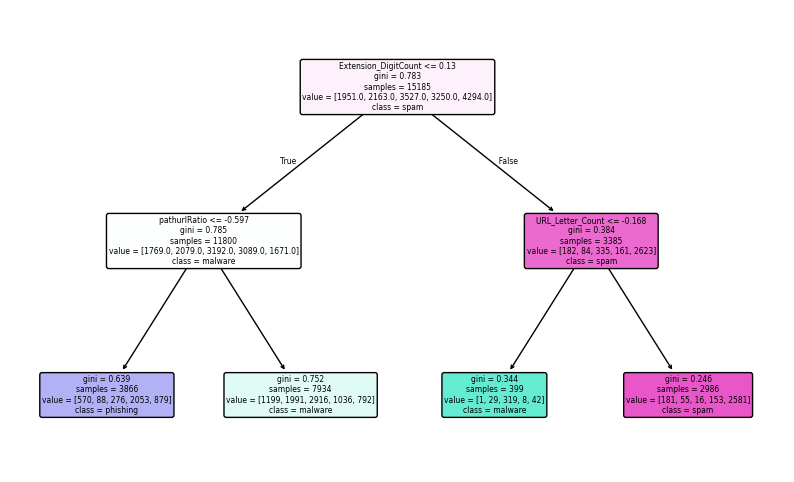

In [33]:
gini2 = DecisionTreeClassifier(criterion = "gini", random_state = 50,
                               max_depth=2)
gini2.fit(X_train, y_train)



plt.figure(figsize=(10,6))
plot_tree(gini2, 
          feature_names=new_names,
          class_names=class_names,
          filled=True, rounded=True)
plt.show()


In [34]:
pred_gini2 = gini2.predict(X_test)

# Accuracy for Decision Tree classifier with criterion as gini index
print("Decision tree gini index accuracy: ", accuracy_score(y_test,pred_gini2) * 100, " %")

Decision tree gini index accuracy:  51.46168027390045  %


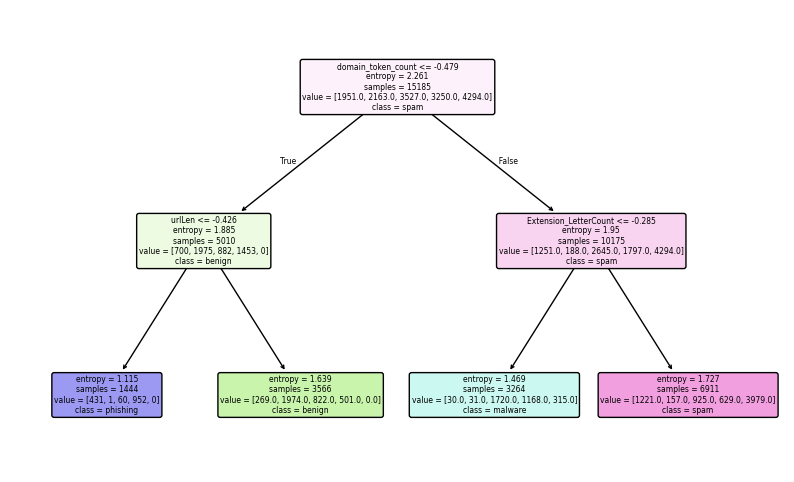

In [35]:
entropy2 = DecisionTreeClassifier(criterion = "entropy", random_state = 50,
    max_depth=2)
entropy2.fit(X_train, y_train)

plt.figure(figsize=(10,6))
plot_tree(entropy2, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()

In [36]:
pred_entropy2 = entropy2.predict(X_test)

print("Decision tree entropy accuracy: ", accuracy_score(y_test,pred_entropy2) * 100, " %")


Decision tree entropy accuracy:  56.01790887542797  %


# Depth 3

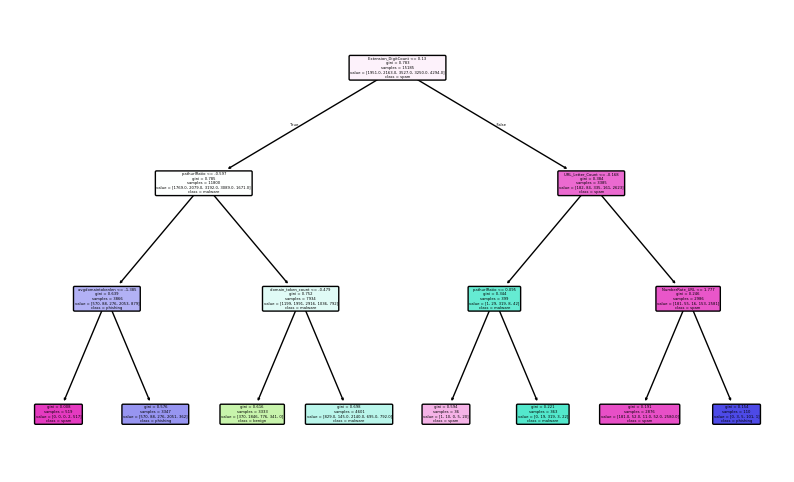

In [37]:
gini3 = DecisionTreeClassifier(criterion = "gini", random_state = 50,
                               max_depth=3)
gini3.fit(X_train, y_train)

plt.figure(figsize=(10,6))
plot_tree(gini3, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()

In [38]:
pred_gini3 = gini3.predict(X_test)


print("Gini accuracy for decision tree: ", accuracy_score(y_test,pred_gini3) * 100, " %")

Gini accuracy for decision tree:  62.812746905451675  %


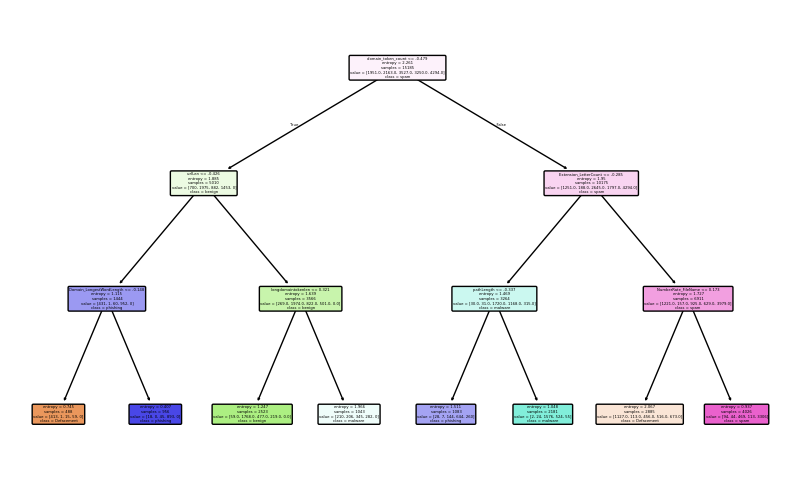

In [ ]:
entropy3 = DecisionTreeClassifier(criterion = "entropy", random_state = 50,
    max_depth=3)
entropy3.fit(X_train, y_train)
plt.figure(figsize=(10,6))
plot_tree(entropy3, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()


In [41]:
pred_entropy3 = entropy3.predict(X_test)


print("Entropy decision tree: ", accuracy_score(y_test,pred_entropy3) * 100, " %")


Entropy decision tree:  67.07927311035029  %


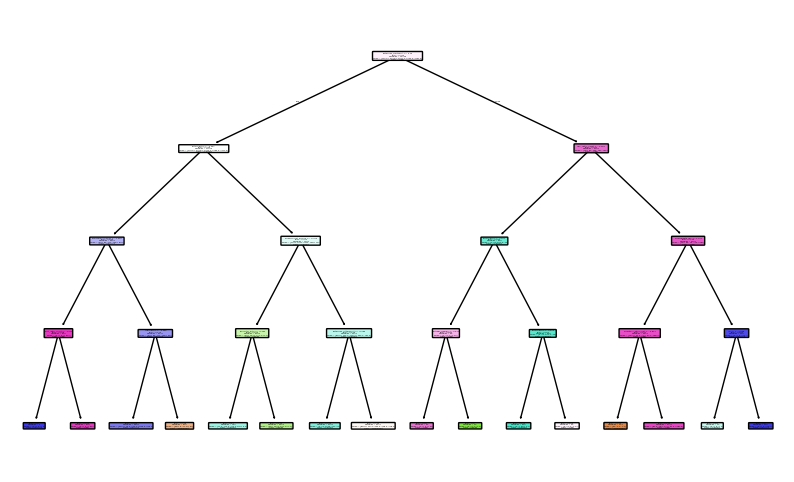

In [ ]:
gini4 = DecisionTreeClassifier(criterion = "gini", random_state = 50,
    max_depth=4)
gini4.fit(X_train, y_train)
plt.figure(figsize=(10,6))
plot_tree(gini4, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()


In [44]:


gini4 = gini4.predict(X_test)

print("Accuracy with gini index: ", accuracy_score(y_test,gini4) * 100, " %")



Accuracy with gini index:  70.05530682117461  %


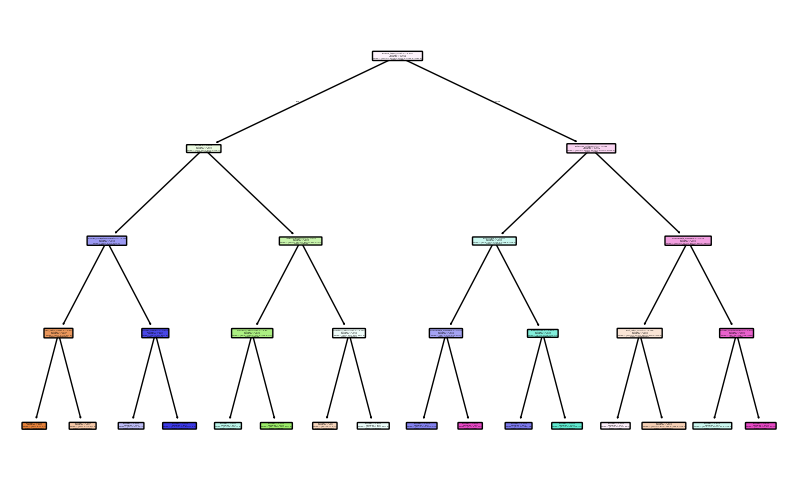

In [45]:
entropy4 = DecisionTreeClassifier(criterion = "entropy", random_state = 50,
     max_depth=4)
entropy4.fit(X_train, y_train)
plt.figure(figsize=(10,6))
plot_tree(entropy4, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()


In [46]:
pred_entropy4 = entropy4.predict(X_test)

# Accuracy for Decision Tree classifier with criterion as gini index
print("Accuracy for entropy decision tree ", accuracy_score(y_test,pred_entropy4) * 100, " %")

Accuracy for entropy decision tree  73.18936002106926  %


# Depth

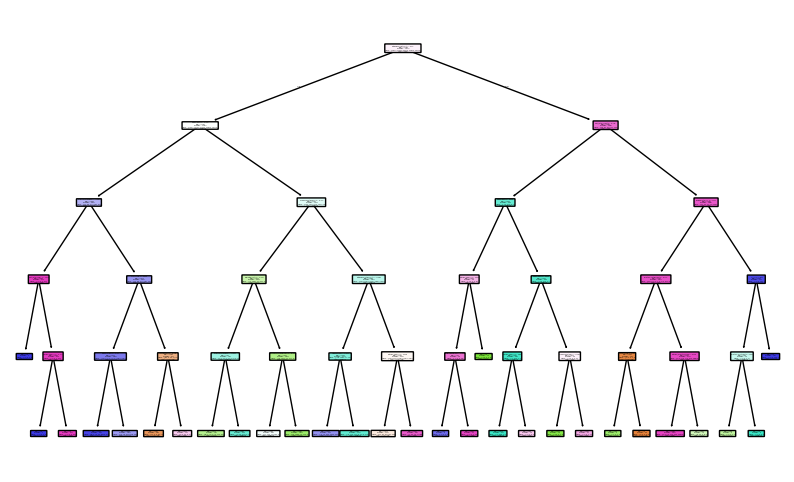

In [48]:


gini5 = DecisionTreeClassifier(criterion = "gini", random_state = 50,
    max_depth=5)
gini5.fit(X_train, y_train)

plt.figure(figsize=(10,6))
plot_tree(gini5, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()

In [49]:
pred_gini5 = gini5.predict(X_test)

print("Accuracy gini decision tree ", accuracy_score(y_test,pred_gini5) * 100, " %")

Accuracy gini decision tree  75.4806426125889  %


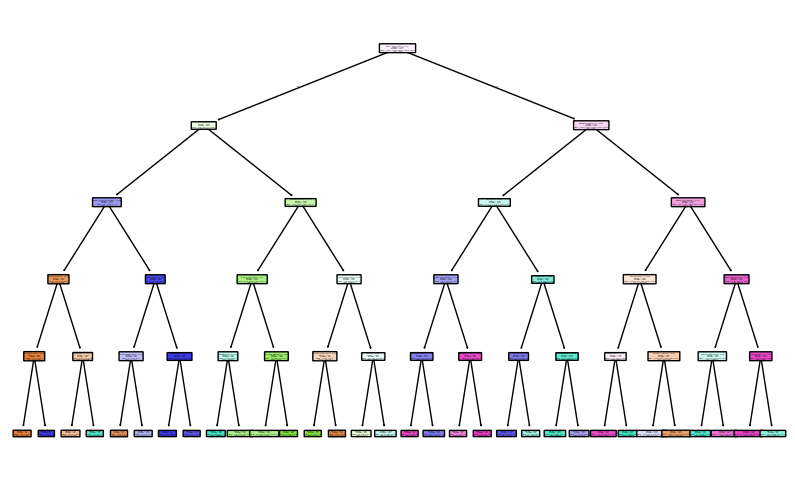

In [ ]:


entropy5 = DecisionTreeClassifier(criterion = "entropy", random_state = 50,
     max_depth=5)
entropy5.fit(X_train, y_train)
plt.figure(figsize=(10,6))
plot_tree(entropy5, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()



In [51]:
pred_entropy5 = entropy5.predict(X_test)
print("Accuracy for entropy decision tree ", accuracy_score(y_test,pred_entropy5) * 100, " %")  


Accuracy for entropy decision tree  80.74795891493284  %


# Depth 6

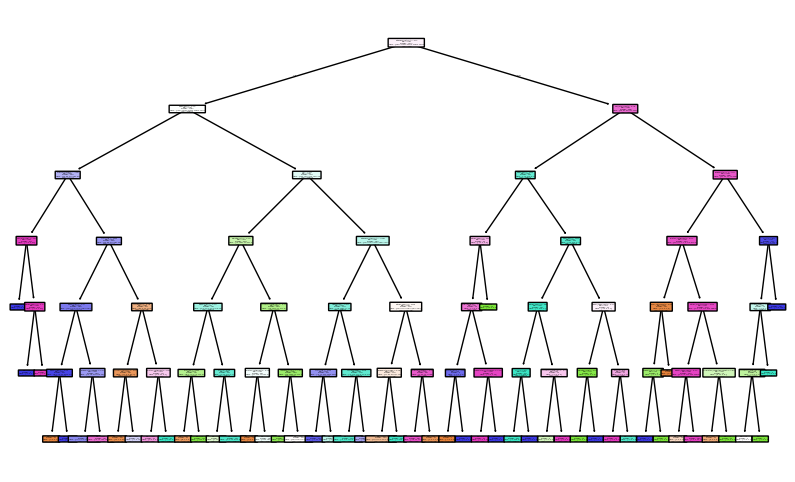

In [55]:


gini6 = DecisionTreeClassifier(criterion = "gini", random_state = 50,
   max_depth=6)
gini6.fit(X_train, y_train)

plt.figure(figsize=(10,6))
plot_tree(gini6, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()




In [56]:
pred_gini6 = gini6.predict(X_test)

# Accuracy for Decision Tree classifier with criterion as gini index
print("Accuracy for Decision Tree  ", accuracy_score(y_test,pred_gini6) * 100, " %")

Accuracy for Decision Tree   81.64340268633131  %


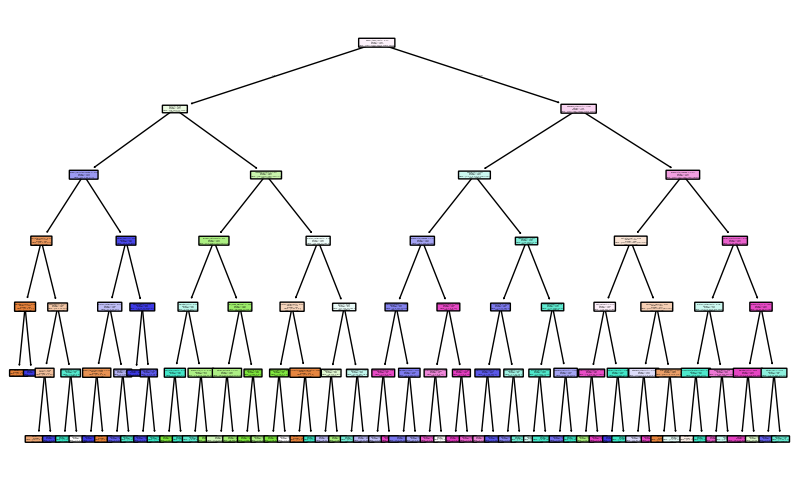

In [57]:

entropy6 = DecisionTreeClassifier(criterion = "entropy", random_state = 50,
    max_depth=6)
entropy6.fit(X_train, y_train)
plt.figure(figsize=(10,6))
plot_tree(entropy6, 
    feature_names=new_names,
    class_names=class_names,
    filled=True, rounded=True)
plt.show()


In [58]:
pred_entropy6 = entropy6.predict(X_test)

# Accuracy for Decision Tree classifier with criterion as gini index
print("Accuracy with Entropy decision tree ", accuracy_score(y_test,pred_entropy6) * 100, " %")

Accuracy with Entropy decision tree  84.77745588622597  %
